# nanoTSFM quickstart

Load the data, train a small model, forecast a series and score it: about two minutes on a GPU, five
on a CPU.

Run `./run.sh setup` first and pick the project's Python kernel. Offline, the notebook uses toy data.

In [1]:
import json
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import yaml

warnings.filterwarnings("ignore", message="IProgress not found")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device: {DEVICE}")

device: cuda


## 1. Data

GEP-M has up to 1,000 series from each of 87 sources in GIFT-Eval Pretrain. A hash of each
series' name puts it in train (80%), validation (10%) or test (10%).

In [2]:
from collections import Counter

from nanotsfm.data import arrays, load

DATA = "GEP-M"
try:
    train_set = load(DATA, "train")
except Exception as error:
    print(f"Hugging Face data unavailable ({type(error).__name__}); using toy data")
    DATA = "toy"
    train_set = load(DATA, "train")
REAL_DATA = DATA == "GEP-M"
print(train_set)
print(f"{len(set(train_set['source']))} sources")
print("frequencies:", dict(Counter(train_set["freq"]).most_common(6)))

Dataset({
    features: ['item_id', 'source', 'freq', 'source_row', 'target'],
    num_rows: 26154
})
87 sources


frequencies: {'D': 6234, '5T': 5002, 'H': 4315, '30T': 1802, 'M': 1728, 'W-SUN': 1542}


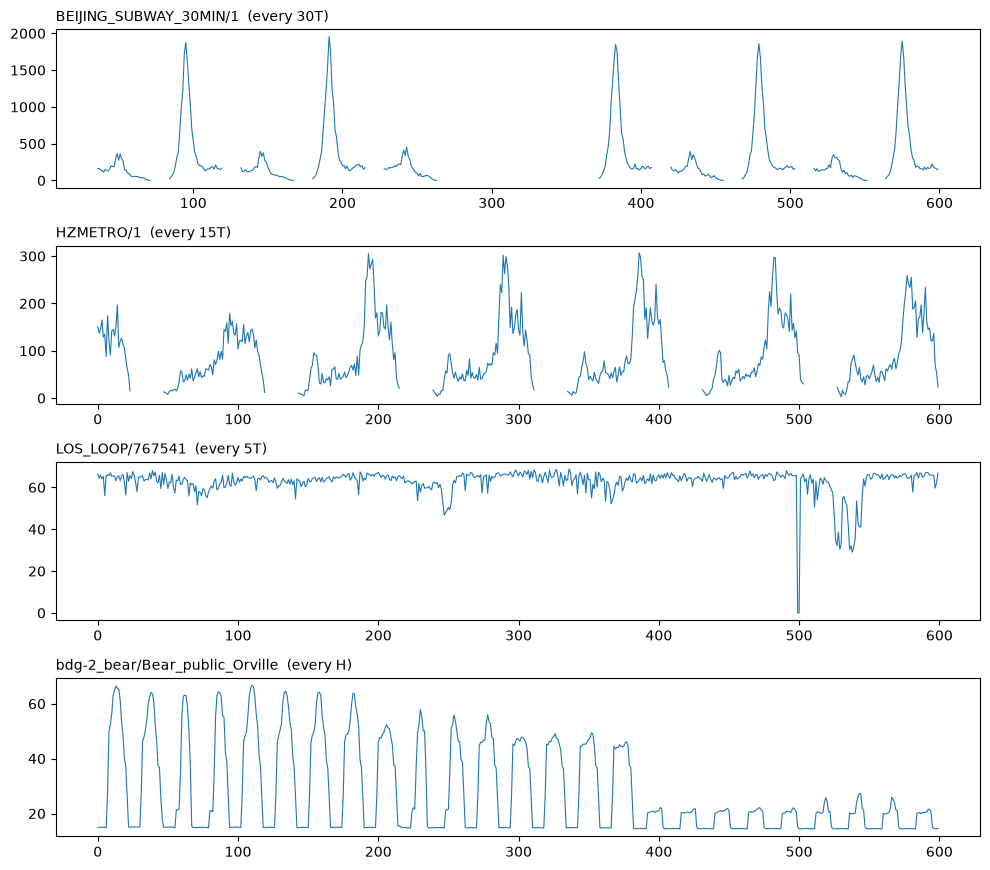

In [3]:
picked, seen = [], set()
for index, freq in enumerate(train_set["freq"]):
    if freq not in seen and len(picked) < 4:
        seen.add(freq)
        picked.append(index)
fig, axes = plt.subplots(len(picked), 1, figsize=(10, 2.2 * len(picked)))
for ax, index in zip(np.atleast_1d(axes), picked, strict=True):
    row = train_set[index]
    ax.plot(row["target"][0][-600:], lw=0.8)
    ax.set_title(f"{row['item_id']}  (every {row['freq']})", fontsize=10, loc="left")
fig.tight_layout()

## 2. Train

`configs/baseline.yaml` trains a 3.3M-parameter model for 5,000 steps, about 2 minutes on an A100.
To stay quick, this runs 1,000 steps on a GPU, or a smaller model for 600 steps on a CPU.

1000 steps in 25 s, 3,326,240 parameters


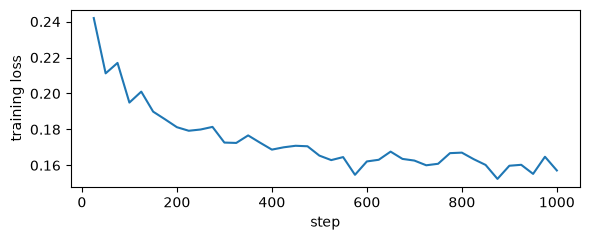

In [4]:
from nanotsfm.train import train

config = yaml.safe_load(Path("configs/baseline.yaml").read_text())
config["training"].update(device=DEVICE, data=DATA)
if DEVICE == "cuda":
    config["training"]["steps"] = 1000
else:
    config["model"].update(context_length=256, prediction_length=64, width=64, layers=2)
    config["training"].update(steps=600, batch_size=64)
if not REAL_DATA:
    config["model"].update(context_length=128, prediction_length=32)

run_dir = Path("outputs") / f"notebook-{time.strftime('%Y%m%d-%H%M%S')}"
config_path = run_dir.parent / f"{run_dir.name}.yaml"
config_path.parent.mkdir(parents=True, exist_ok=True)
config_path.write_text(yaml.safe_dump(config))
checkpoint = train(config_path, run_dir)

run = json.loads((run_dir / "run.json").read_text())
print(f"{run['steps']} steps in {run['elapsed_seconds']:.0f} s, {run['parameters']:,} parameters")
log = [json.loads(line) for line in open(run_dir / "training.jsonl") if '"loss"' in line]
plt.figure(figsize=(6, 2.5))
plt.plot([r["step"] for r in log], [r["loss"] for r in log])
plt.xlabel("step")
plt.ylabel("training loss")
plt.tight_layout()

## 3. Forecast

The model returns nine quantiles, 10% to 90%, for each future step. The band spans 10–90%; the line
is the median.

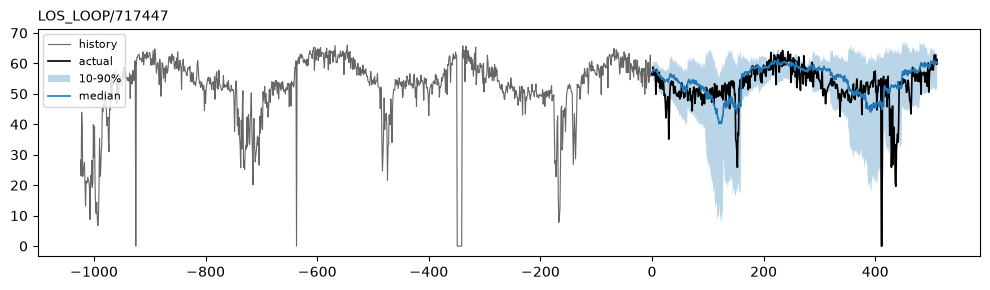

In [5]:
from nanotsfm.model import forecast, load_checkpoint

model, _ = load_checkpoint(checkpoint, DEVICE)
context, horizon = model.config.context_length, model.config.prediction_length
validation = load(DATA, "validation")
index, values = next(
    (i, v[0])
    for i, v in enumerate(arrays(validation))
    if v.shape[0] == 1 and v.shape[1] >= context + horizon
)
history, future = values[-(context + horizon) : -horizon], values[-horizon:]
quantiles = forecast(model, torch.tensor(history)[None], horizon)[0].cpu().numpy()

steps = np.arange(-len(history), horizon)
plt.figure(figsize=(10, 3))
plt.plot(steps[: len(history)], history, color="0.4", lw=0.8, label="history")
plt.plot(steps[len(history) :], future, color="black", lw=1.2, label="actual")
plt.fill_between(steps[len(history) :], quantiles[:, 0], quantiles[:, 8], alpha=0.3, label="10-90%")
plt.plot(steps[len(history) :], quantiles[:, 4], lw=1.2, label="median")
plt.title(validation[index]["item_id"], loc="left", fontsize=10)
plt.legend(loc="upper left", fontsize=8)
plt.tight_layout()

## 4. GEP-Val

GEP-Val forecasts held-out series from the training sources and scores each task against Seasonal
Naive. Below 1 beats Seasonal Naive.

In [6]:
from nanotsfm.evaluation import evaluate_heldout

if REAL_DATA:
    output = evaluate_heldout(checkpoint, "validation", run_dir / "gep-val.json", DEVICE)
    result = json.loads(output.read_text())
    crps = "mean_weighted_sum_quantile_loss"
    ratios = sorted(
        (r["metrics"][crps] / r["seasonal_naive"][crps], r["dataset"], r["term"])
        for r in result["rows"]
    )
    print("best tasks: ", [(d, t, round(x, 2)) for x, d, t in ratios[:3]])
    print("worst tasks:", [(d, t, round(x, 2)) for x, d, t in ratios[-3:]])
else:
    print("GEP-Val needs the Hugging Face data.")

GEP-Val: relative CRPS 0.6720, relative MASE 0.8485 over 129 tasks
best tasks:  [('BEIJING_SUBWAY_30MIN', 'short', 0.16), ('kdd2022', 'short', 0.28), ('BEIJING_SUBWAY_30MIN', 'long', 0.29)]
worst tasks: [('pedestrian_counts', 'medium', 1.19), ('wind_farms_with_missing', 'medium', 1.23), ('HZMETRO', 'short', 1.31)]


## 5. GIFT-Eval

The score: 97 tasks from 23 datasets the model never trains on, relative to Seasonal Naive. It takes
about 4 minutes on 8 CPU cores:

```shell
./run.sh train my-run
./run.sh eval my-run
```

The baseline scores 0.666. When GEP-Val improves but GIFT-Eval does not, the model is fitting its
training data rather than learning to forecast.

## 6. Next steps

- Change the model, training or data in `src/nanotsfm/`.
- Copy `configs/baseline.yaml`, edit it, and run `./run.sh train my-run path/to/config.yaml`.
- Read the [directions](docs/directions.md) for ideas and the [rules](docs/rules.md).